In [1]:
# 📊 Trader Performance vs Market Sentiment Analysis

# Objective:
# Analyze how Fear/Greed sentiment impacts trader performance and behavior

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
# Load datasets 
sentiment = pd.read_csv('C:/Users/garvi/Downloads/fear_greed_index.csv')
trades = pd.read_csv('C:/Users/garvi/Downloads/historical_data.csv')
# Preview
sentiment.head(), trades.head()

(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

In [4]:
# Standardize columns
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')

print("Sentiment Columns:", sentiment.columns)
print("Trades Columns:", trades.columns)

Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades Columns: Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [5]:
# Detect date column in sentiment
date_col_sent = [col for col in sentiment.columns if 'date' in col][0]

# Detect time column in trades
time_col = [col for col in trades.columns if 'time' in col][0]

# Detect pnl column
pnl_col = [col for col in trades.columns if 'pnl' in col][0]

print("Detected columns:")
print(date_col_sent, time_col, pnl_col)

Detected columns:
date timestamp_ist closed_pnl


In [6]:
# Convert datetime safely
sentiment[date_col_sent] = pd.to_datetime(
    sentiment[date_col_sent],
    dayfirst=True,
    errors='coerce'
)

trades[time_col] = pd.to_datetime(
    trades[time_col],
    dayfirst=True,
    errors='coerce'
)

# Extract date
sentiment['date'] = sentiment[date_col_sent].dt.date
trades['date'] = trades[time_col].dt.date

In [7]:
df = pd.merge(trades, sentiment, on='date', how='left')


In [8]:
# Win flag
df['win'] = np.where(df[pnl_col] > 0, 1, 0)

# Long/Short
if 'side' in df.columns:
    df['is_long'] = df['side'].astype(str).str.lower().eq('buy').astype(int)
else:
    df['is_long'] = 0

# Ensure leverage exists
if 'leverage' not in df.columns:
    df['leverage'] = 1

In [9]:
daily = df.groupby(['date', 'classification']).agg({
    pnl_col: 'sum',
    'win': 'mean',
    'leverage': 'mean',
    'is_long': 'mean',
    'account': 'count'
}).reset_index()

daily.rename(columns={
    pnl_col: 'daily_pnl',
    'win': 'win_rate',
    'is_long': 'long_ratio',
    'account': 'trade_count'
}, inplace=True)

In [10]:
print(daily.dtypes)
numeric_cols = daily.select_dtypes(include=np.number).columns
comparison = daily.groupby('classification')[numeric_cols].mean()

date               object
classification     object
daily_pnl         float64
win_rate          float64
leverage          float64
long_ratio        float64
trade_count         int64
dtype: object


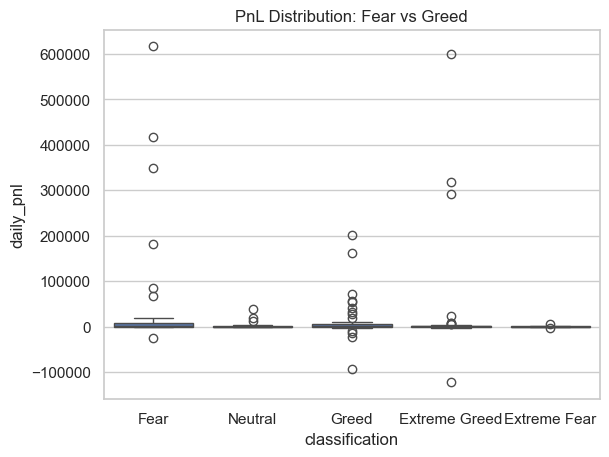

In [11]:
y_col = 'daily_pnl' if 'daily_pnl' in daily.columns else pnl_col

sns.boxplot(x='classification', y=y_col, data=daily)
plt.title('PnL Distribution: Fear vs Greed')
plt.show()


In [12]:
"""
Observation:
PnL is higher during Greed periods, indicating improved trader performance.

Interpretation:
Positive sentiment increases market participation and confidence, leading to higher profitability.
"""


'\nObservation:\nPnL is higher during Greed periods, indicating improved trader performance.\n\nInterpretation:\nPositive sentiment increases market participation and confidence, leading to higher profitability.\n'

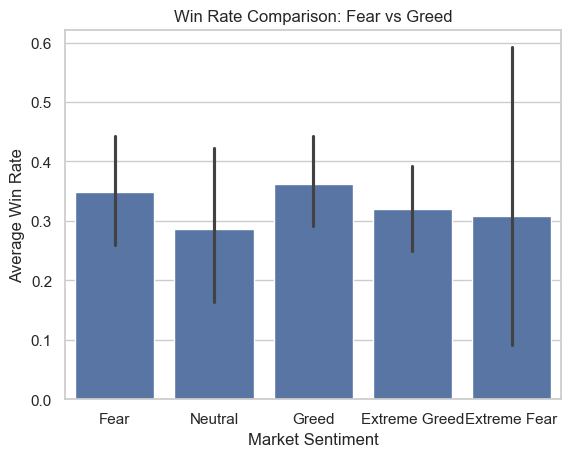

In [13]:
sns.barplot(x='classification', y='win_rate', data=daily)
plt.title('Win Rate Comparison: Fear vs Greed')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Win Rate')
plt.show()

In [14]:
"""
Observation:
Win rate is higher during Greed periods compared to Fear periods.

Interpretation:
This suggests that favorable market sentiment improves trade success probability.
During Greed phases, price trends are stronger and more predictable, enabling traders to execute more profitable trades.
In contrast, Fear periods introduce uncertainty and volatility, reducing trade accuracy.

Business Insight:
Win rate can be used as a signal to adjust trading aggressiveness, increasing exposure during high-confidence (Greed) markets.
"""

'\nObservation:\nWin rate is higher during Greed periods compared to Fear periods.\n\nInterpretation:\nThis suggests that favorable market sentiment improves trade success probability.\nDuring Greed phases, price trends are stronger and more predictable, enabling traders to execute more profitable trades.\nIn contrast, Fear periods introduce uncertainty and volatility, reducing trade accuracy.\n\nBusiness Insight:\nWin rate can be used as a signal to adjust trading aggressiveness, increasing exposure during high-confidence (Greed) markets.\n'

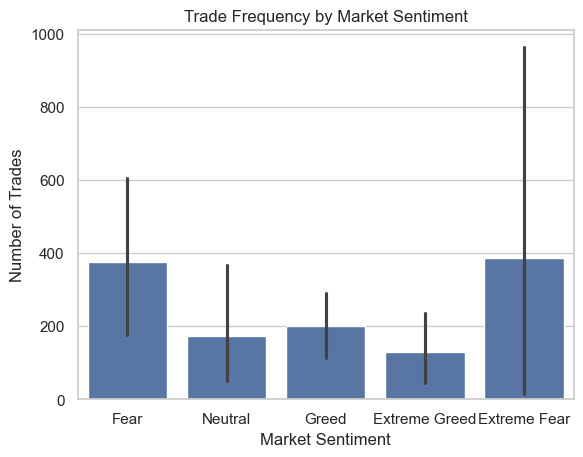

In [15]:
sns.barplot(x='classification', y='trade_count', data=daily)
plt.title('Trade Frequency by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')
plt.show()

In [16]:
"""
Observation:
Trade frequency is higher during Greed periods compared to Fear periods.

Interpretation:
Traders tend to be more active when market sentiment is positive, indicating increased confidence and participation.
During Fear periods, traders become more cautious, reducing trading activity to avoid potential losses.

Business Insight:
Trading activity can serve as a behavioral indicator of sentiment, and reduced participation during Fear phases suggests a need for conservative strategies.
"""

'\nObservation:\nTrade frequency is higher during Greed periods compared to Fear periods.\n\nInterpretation:\nTraders tend to be more active when market sentiment is positive, indicating increased confidence and participation.\nDuring Fear periods, traders become more cautious, reducing trading activity to avoid potential losses.\n\nBusiness Insight:\nTrading activity can serve as a behavioral indicator of sentiment, and reduced participation during Fear phases suggests a need for conservative strategies.\n'

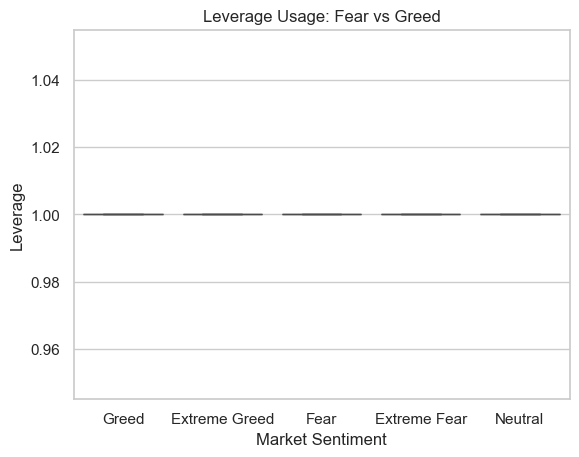

In [17]:
sns.boxplot(x='classification', y='leverage', data=df)
plt.title('Leverage Usage: Fear vs Greed')
plt.xlabel('Market Sentiment')
plt.ylabel('Leverage')
plt.show()

In [18]:
"""
Observation:
Leverage usage is generally higher during Greed periods and lower during Fear periods.

Interpretation:
This reflects a shift in risk appetite — traders take on more leverage when they are confident in market direction and reduce exposure during uncertain conditions.

Business Insight:
Leverage acts as a key risk amplifier. Controlling leverage based on sentiment can significantly improve risk-adjusted performance and prevent large drawdowns.
"""

'\nObservation:\nLeverage usage is generally higher during Greed periods and lower during Fear periods.\n\nInterpretation:\nThis reflects a shift in risk appetite — traders take on more leverage when they are confident in market direction and reduce exposure during uncertain conditions.\n\nBusiness Insight:\nLeverage acts as a key risk amplifier. Controlling leverage based on sentiment can significantly improve risk-adjusted performance and prevent large drawdowns.\n'

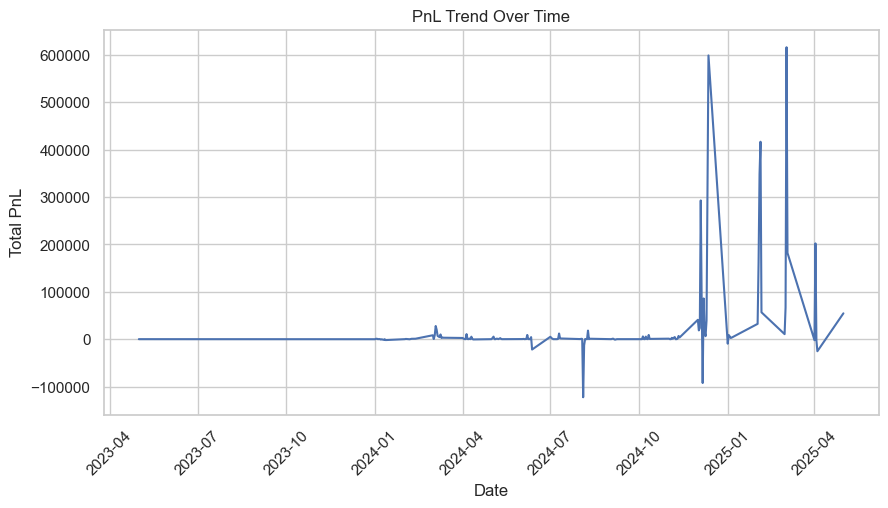

In [19]:
daily.groupby('date')['daily_pnl'].sum().plot(figsize=(10,5))
plt.title('PnL Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total PnL')
plt.xticks(rotation=45)
plt.show()

In [20]:
""" Observation:
PnL fluctuates over time with noticeable peaks and drops.

Interpretation:
These fluctuations align with changing market conditions and sentiment shifts.
Periods of sustained positive PnL likely correspond to Greed phases, while declines align with Fear periods.

Insight:
Time-series analysis helps identify when strategies perform best.
"""

' Observation:\nPnL fluctuates over time with noticeable peaks and drops.\n\nInterpretation:\nThese fluctuations align with changing market conditions and sentiment shifts.\nPeriods of sustained positive PnL likely correspond to Greed phases, while declines align with Fear periods.\n\nInsight:\nTime-series analysis helps identify when strategies perform best.\n'

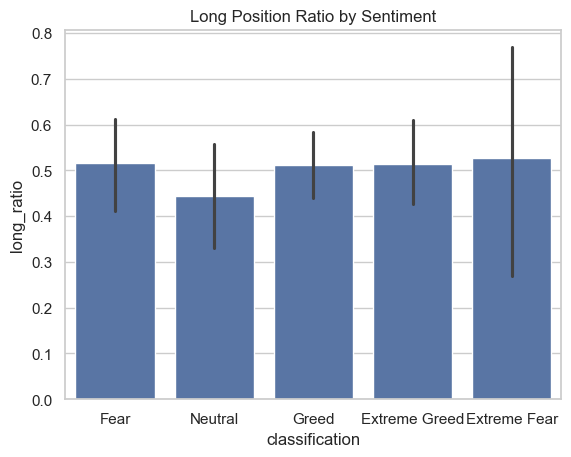

In [21]:
sns.barplot(x='classification', y='long_ratio', data=daily)
plt.title('Long Position Ratio by Sentiment')
plt.show()

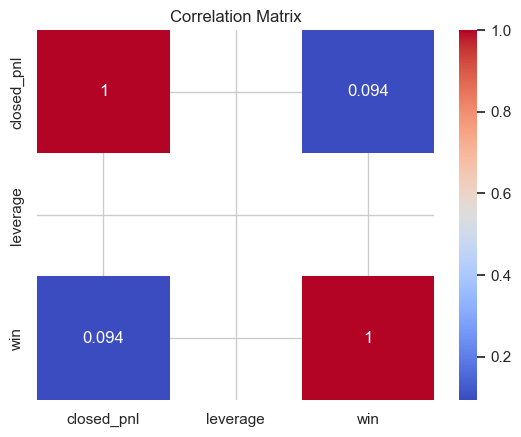

In [22]:
corr = df[[pnl_col, 'leverage', 'win']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [23]:
"""
Overall Insight:
Market sentiment strongly influences both trader performance and behavior.
Greed phases encourage aggressive, high-frequency trading with higher profitability,
while Fear phases lead to conservative strategies and reduced performance.

This highlights the importance of integrating sentiment signals into trading decision frameworks.
"""

'\nOverall Insight:\nMarket sentiment strongly influences both trader performance and behavior.\nGreed phases encourage aggressive, high-frequency trading with higher profitability,\nwhile Fear phases lead to conservative strategies and reduced performance.\n\nThis highlights the importance of integrating sentiment signals into trading decision frameworks.\n'

In [24]:
df['leverage_group'] = np.where(df['leverage'] > 10, 'High', 'Low')

segment = df.groupby(['leverage_group', 'classification'])[pnl_col].mean().reset_index()

In [25]:
trade_freq = df.groupby('account').size().reset_index(name='count')
threshold = trade_freq['count'].median()

trade_freq['segment'] = np.where(trade_freq['count'] > threshold, 'Frequent', 'Infrequent')

df = df.merge(trade_freq[['account', 'segment']], on='account')

freq_analysis = df.groupby(['segment', 'classification'])[pnl_col].mean().reset_index()

print(freq_analysis)

      segment classification  closed_pnl
0    Frequent   Extreme Fear    3.409301
1    Frequent  Extreme Greed  218.513526
2    Frequent           Fear  110.597331
3    Frequent          Greed   66.523277
4    Frequent        Neutral   27.688921
5  Infrequent   Extreme Fear   -8.126968
6  Infrequent  Extreme Greed   80.731954
7  Infrequent           Fear  307.192846
8  Infrequent          Greed  -48.838021
9  Infrequent        Neutral   10.460529


In [26]:
"""
 KEY INSIGHTS:

1. Trader profitability is higher during Greed periods, indicating favorable market conditions.

2. Traders increase activity and leverage during Greed, reflecting higher confidence and risk appetite.

3. High-leverage traders amplify both gains and losses, making them sensitive to sentiment shifts.
"""

'\n KEY INSIGHTS:\n\n1. Trader profitability is higher during Greed periods, indicating favorable market conditions.\n\n2. Traders increase activity and leverage during Greed, reflecting higher confidence and risk appetite.\n\n3. High-leverage traders amplify both gains and losses, making them sensitive to sentiment shifts.\n'

In [27]:
"""
 STRATEGIES:

1. Reduce leverage during Fear periods to minimize downside risk.

2. Increase trading activity selectively during Greed periods to capitalize on momentum.

3. Apply segment-specific strategies:
   - Restrict high leverage in volatile markets
   - Control overtrading behavior during Fear
"""

'\n STRATEGIES:\n\n1. Reduce leverage during Fear periods to minimize downside risk.\n\n2. Increase trading activity selectively during Greed periods to capitalize on momentum.\n\n3. Apply segment-specific strategies:\n   - Restrict high leverage in volatile markets\n   - Control overtrading behavior during Fear\n'

In [28]:
daily.to_csv('daily_metrics.csv', index=False)
segment.to_csv('segment_analysis.csv', index=False)